Distance between points: 937.08 meters


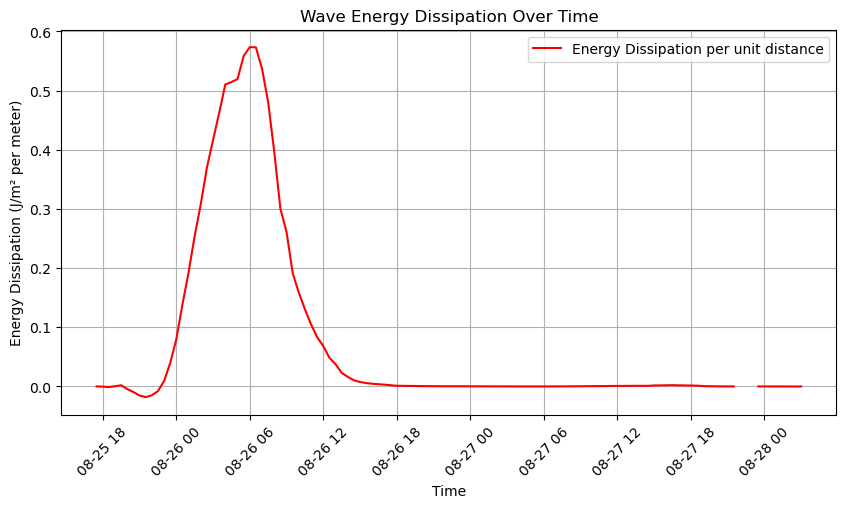

In [5]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# Path to your DFSU file
dfsu_file = r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu"

# Load DFSU file
ds = mikeio.open(dfsu_file)

# Given points (before and after reef)
point_before = (732881, 3177325)
point_after = (732478, 3178171)

# Find nearest elements to the given points
id_before = ds.geometry.find_nearest_elements(x=point_before[0], y=point_before[1])
id_after = ds.geometry.find_nearest_elements(x=point_after[0], y=point_after[1])

# Extract significant wave height (Hs) at those points
Hs_before = ds.read(items="Sign. Wave Height").isel(element=id_before)
Hs_after = ds.read(items="Sign. Wave Height").isel(element=id_after)

# Time array
time = Hs_before.time

# Compute wave energy (E)
rho = 1025  # Seawater density (kg/m³)
g = 9.81    # Gravity (m/s²)
E_before = (1/8) * rho * g * (Hs_before.to_numpy()**2)

E_after = (1/8) * rho * g * (Hs_after.to_numpy()**2)

# Calculate distance between points
distance = np.sqrt((point_before[0] - point_after[0])**2 + (point_before[1] - point_after[1])**2)
print(f"Distance between points: {distance:.2f} meters")

# Compute Energy Dissipation per unit distance
D = (E_before - E_after) / distance  

# Plot Energy Dissipation per unit distance
plt.figure(figsize=(10, 5))
plt.plot(time, D.squeeze(), label="Energy Dissipation per unit distance", color='red')

plt.xlabel("Time")
plt.ylabel("Energy Dissipation (J/m² per meter)")
plt.title("Wave Energy Dissipation Over Time")
plt.legend()
plt.grid()
plt.xticks(rotation=45)
plt.show()


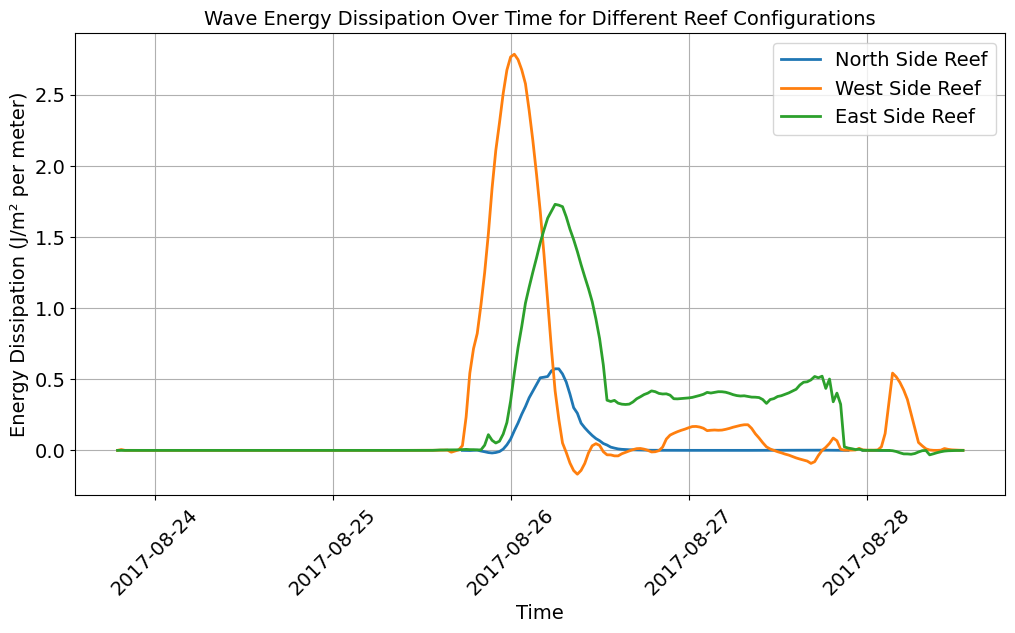

In [2]:
import mikeio
import numpy as np
import matplotlib.pyplot as plt

# Define file paths and points
scenarios = {
    "North Side Reef": {
        "file": r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\Small_scale_Wave_Model_Cyclone_Harvey_with_reef_barrier_reef_Pattern.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu",
        "before": (732881, 3177325),
        "after": (732478, 3178171),
    },
    "West Side Reef": {
        "file": r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\West_side_barrier_reef.sw - Result Files\small_scale_wave_result_with_barrier_reef.dfsu",
        "before": (731342, 3175678),
        "after": (730769, 3175291),
    },
    "East Side Reef": {
        "file": r"D:\Phd Research\Wave Model\small scale port lavaca\Simulation\east_side_barrier_reef.sw - Result Files\east_side_reef.dfsu",
        "before": (735378, 3176602),
        "after": (735945, 3177003),
    },
}

# Constants
rho = 1025  # Seawater density (kg/m³)
g = 9.81    # Gravity (m/s²)
# Increase all default font sizes
plt.rcParams.update({
    'font.size': 14,         # base font size for text
    'axes.titlesize': 14,    # title
    'axes.labelsize': 14,    # x/y labels
    'xtick.labelsize': 14,   # x tick labels
    'ytick.labelsize': 14,   # y tick labels
    'legend.fontsize': 14    # legend
})
# Initialize plot
plt.figure(figsize=(12, 6))

# Process each scenario
for label, data in scenarios.items():
    # Load DFSU file
    ds = mikeio.open(data["file"])
    
    # Find nearest elements
    id_before = ds.geometry.find_nearest_elements(x=data["before"][0], y=data["before"][1])
    id_after = ds.geometry.find_nearest_elements(x=data["after"][0], y=data["after"][1])
    
    # Read significant wave height (Hs)
    ds_data = ds.read(items="Sign. Wave Height")
    Hs_before = ds_data.isel(element=id_before).to_numpy()
    Hs_after = ds_data.isel(element=id_after).to_numpy()
    time = ds_data.time
    
    # Compute wave energy (E)
    E_before = (1/8) * rho * g * (Hs_before**2)
    E_after = (1/8) * rho * g * (Hs_after**2)
    
    # Compute distance between points
    distance = np.sqrt((data["before"][0] - data["after"][0])**2 + (data["before"][1] - data["after"][1])**2)
    
    # Compute Energy Dissipation per unit distance
    D = (E_before - E_after) / distance  

    # Plot
    plt.plot(time, D.squeeze(), label=f"{label}", linewidth=2)

# Formatting
plt.xlabel("Time")
plt.ylabel("Energy Dissipation (J/m² per meter)")
plt.title("Wave Energy Dissipation Over Time for Different Reef Configurations")
plt.legend()
plt.grid()
plt.xticks(rotation=45)

# Show plot
plt.show()
